In [ ]:
!pip install scanpy pandas numpy squidpy matplotlib anndata igraph seaborn ptitprince

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 42.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16217 sha256=a2c3ff626990eed7e40f4ef64b07c52dff273e33e93a0863b78fe8e87b273f1e
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


In [ ]:
# -- Imports
import os
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import igraph
import seaborn as sns
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
import ptitprince as pt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
# -- COLOR PALETTES

spatial_palette  = [
    "#E69F00",
    "#00538A",
    "#BFBFBF",
    "#969696",
    "#009E73",
    "#6E6E6E",
    "#D55E00",
    "#A6BDD7",
    "#404040",
]

immune_palette = [
    "#D55E00",
    "#E69F00",
    "#8F8F8F",
    "#D9D9D9"

]

immune_palette_map = {
    "Immune-high": "#D55E00",
    "Immune-moderate": "#E69F00",
    "Immune-low": "#8F8F8F",
    "Immune-poor": "#D9D9D9"
}



In [ ]:
# -- Paths
input_path_sc_posterior = "/content/drive/MyDrive/endo-immune-atlas/data/processed/immune_reference_posterior.h5ad"

input_path_BEME_346_posterior = "/content/drive/MyDrive/endo-immune-atlas/data/processed/adata_346_posterior.h5ad"

input_path_BEME_355G_posterior = "/content/drive/MyDrive/endo-immune-atlas/data/processed/adata_355G_posterior.h5ad"

output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"
output_path_figures = "/content/drive/MyDrive/endo-immune-atlas/results/final_figures"

os.makedirs(output_path_figures, exist_ok=True)

In [ ]:
# -- Import objects
immune_posterior = sc.read_h5ad(input_path_sc_posterior)
adata_346 = sc.read_h5ad(input_path_BEME_346_posterior)
adata_355G = sc.read_h5ad(input_path_BEME_355G_posterior)

In [ ]:
#===========================================================
# TISSUE #1: BEME_346
#===========================================================

# add 5% quantile, representing confident cell abundance
adata_346.obs[adata_346.uns['mod']['factor_names']] = adata_346.obsm['q05_cell_abundance_w_sf']

# -- KNN
sc.pp.neighbors(adata_346, use_rep='q05_cell_abundance_w_sf',
                n_neighbors = 15)

# Cluster spots into regions using scanpy

for res in [0.2, 0.4, 0.6, 0.8]:
    sc.tl.leiden(
        adata_346,
        resolution=res,
        flavor="igraph",
        key_added=f"leiden_{res}"
    )

# add region as categorical variable
adata_346.obs["region_cluster"] = adata_346.obs["leiden_0.4"].astype("category")

In [ ]:
#==============================================================
# FIGURE 8_1: CLUSTERING
#==============================================================

sq.pl.spatial_scatter(
    adata_346,
    color=["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8"],
    ncols=2,
    size=1.5,
    img=False
)

plt.savefig(
    os.path.join(output_path_figures, "08_346_leiden_clusters.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#==============================================================
# FIGURE 8_2: UMAP
#==============================================================

sc.tl.umap(adata_346, min_dist = 0.3, spread = 1)

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_346, color=['leiden_0.4'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20, palette=spatial_palette, show=False)

plt.savefig(
    os.path.join(output_path_figures, "08_346_spatial_UMAP.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
cell_columns = [
    "Classical Monocytes",
    "Non-Classical Monocytes",
    "Tissue Resident Macrophages",
    "Dendritic cells",
    "CD16+ NK cells",
    "CD16- NK cells",
    "CD4 T cells",
    "Tregs",
    "CD8 T cells",
    "γδ T cells",
    "B cells",
]

region_means_346 = (
    adata_346.obs
    .groupby("leiden_0.4")[cell_columns]
    .mean()
)

/tmp/ipykernel_21433/1725475880.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")[cell_columns]


In [ ]:
# -- TOTAL IMMUNE ABUNDANCE
region_means_346["total_immune"] = region_means_346[cell_columns].sum(axis=1)

# Spot level
adata_346.obs["total_immune_spot_level"] = adata_346.obs[cell_columns].sum(axis=1)

# Region level
adata_346.obs["total_immune_region_level"] = (adata_346.obs["leiden_0.4"].astype(str).map(region_means_346["total_immune"])
)

In [ ]:
#===========================================================
# FIGURE 8_3: CELL TYPES IN SPATIAL
#===========================================================

plot_cols = cell_columns + ["total_immune_spot_level"]

ncols = 4
nrows = int(np.ceil(len(cell_columns) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 10)
)

axes = axes.flatten()

for ax, plots in zip(axes, plot_cols):
  sq.pl.spatial_scatter(
      adata_346,
      color=plots,
      cmap="magma",
      img=True,
      size=1.5,
      ax=ax
    )
  title = "Total Immune" if plots == "total_immune_spot_level" else plots
  ax.set_title(title, fontsize=11)


fig.subplots_adjust(
    wspace=0.05,
    hspace=0.25
)

plt.savefig(
    os.path.join(output_path_figures, "08_346_spatial_architecture_cell_type.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()



Text(0.5, 0, 'Region')

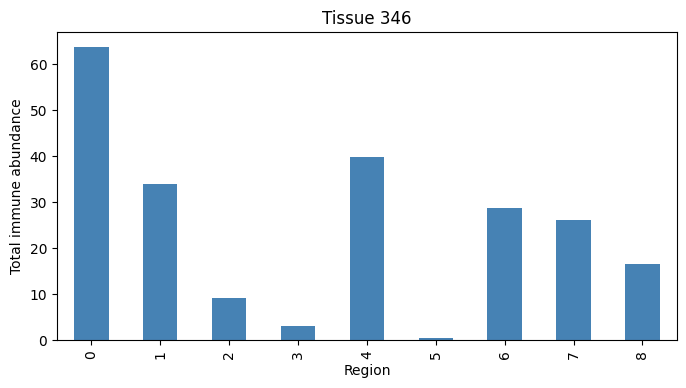

In [ ]:
#==============================================================
# FIGURE 8_4: TOTAL IMMUNE ABUNDANCE
#==============================================================
region_means_346["total_immune"].plot.bar(
    figsize=(8,4),
    color="steelblue"
)
plt.title("Tissue 346")
plt.ylabel("Total immune abundance")
plt.xlabel("Region")


plt.savefig(
    os.path.join(output_path_figures, "08_346_total_immune_abundance.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#==============================================================
# FIGURE 8_5: PROPORTION OF CELL TYPE PER REGION - HEATMAP
#==============================================================
sns.clustermap(
    region_means_346[cell_columns],
    row_cluster=True,
    col_cluster=False,
    cmap="RdBu_r",
    center=0
)

plt.savefig(
    os.path.join(output_path_figures, "08_346_total_immune_abundance_cell_type_heatmap.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
# -- LABEL CLUSTERS BASED ON TISSUE LEVEL ABUNDANCES
tissue_346_region_class = {
    "0": "Immune-high",
    "1": "Immune-high",
    "2": "Immune-poor",
    "3": "Immune-poor",
    "4": "Immune-high",
    "5": "Immune-poor",
    "6": "Immune-moderate",
    "7": "Immune-moderate",
    "8": "Immune-low"
}

adata_346.obs["tissue_level_immune_class"] = adata_346.obs["leiden_0.4"].astype(str).map(tissue_346_region_class)

immune_class_order = [
    "Immune-high",
    "Immune-moderate",
    "Immune-low",
    "Immune-poor"
]

adata_346.obs["tissue_level_immune_class"] = pd.Categorical(
    adata_346.obs["tissue_level_immune_class"],
    categories=immune_class_order,
    ordered=True
)

/tmp/ipykernel_21433/3783521392.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")["tissue_level_immune_class"]


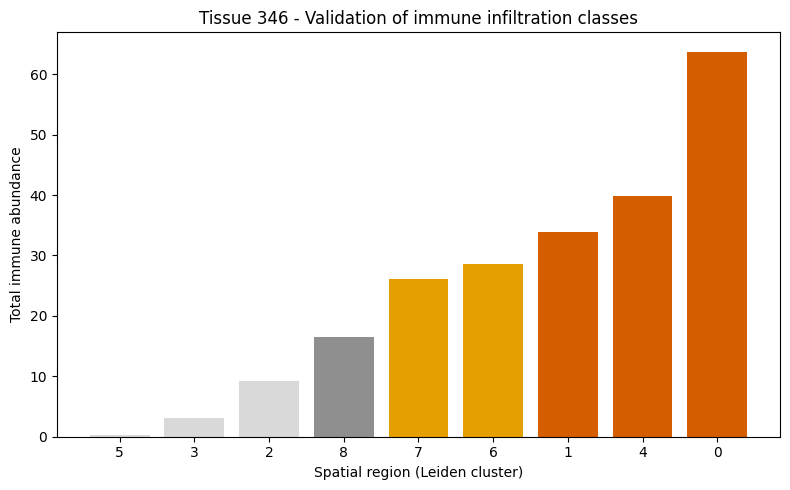

In [ ]:
#==============================================================
# FIGURE 8_X: VALIDATING IMMUNE CLASSES
#==============================================================
region_class_346 = (
    adata_346.obs
    .groupby("leiden_0.4")["tissue_level_immune_class"]
    .first()
)
region_means_346["tissue_level_immune_class"] = region_class_346


# Order regions by abundance
plot_df = region_means_346.sort_values("total_immune").copy()

# Assign colors
colors = plot_df["tissue_level_immune_class"].map(immune_palette_map)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    plot_df.index.astype(str),
    plot_df["total_immune"],
    color=colors
)

plt.xlabel("Spatial region")
plt.ylabel("Total immune abundance")
plt.title("Tissue 346 - Validation of immune infiltration classes")

plt.tight_layout()
plt.show()

In [ ]:
# -- Apparently you need to do all of this to color code a spatial object....
adata_346.obs["tissue_level_immune_class"] = (
    adata_346.obs["tissue_level_immune_class"]
    .astype("category")
)

adata_346.obs["tissue_level_immune_class"] = (
    adata_346.obs["tissue_level_immune_class"]
    .cat.reorder_categories(
        ["Immune-poor", "Immune-low", "Immune-moderate", "Immune-high"],
        ordered=True
    )
)

adata_346.uns["tissue_level_immune_class_colors"] = [
    immune_palette_map[c]
    for c in adata_346.obs["tissue_level_immune_class"].cat.categories
]

In [ ]:
#==============================================================
# FIGURE 8_6: IMMUNE REGION CLASSES
#==============================================================
sq.pl.spatial_scatter(
    adata_346,
    color="tissue_level_immune_class",
    size=1.5,
    img=False
)

plt.title("Immune Regions - Tissue 346")

plt.savefig(
    os.path.join(output_path_figures, "08_346_spatial_immune_region_class.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#===========================================================
# TISSUE #2: BEME_355G
#===========================================================

# add 5% quantile, representing confident cell abundance
adata_355G.obs[adata_355G.uns['mod']['factor_names']] = adata_355G.obsm['q05_cell_abundance_w_sf']

# -- KNN
sc.pp.neighbors(adata_355G, use_rep='q05_cell_abundance_w_sf',
                n_neighbors = 15)

# Cluster spots into regions using scanpy

for res in [0.2, 0.4, 0.6, 0.8]:
    sc.tl.leiden(
        adata_355G,
        resolution=res,
        flavor="igraph",
        key_added=f"leiden_{res}"
    )

# add region as categorical variable
adata_355G.obs["region_cluster"] = adata_355G.obs["leiden_0.4"].astype("category")

In [ ]:
#==============================================================
# FIGURE 8_7: CLUSTERING TISSUE #2
#==============================================================
sq.pl.spatial_scatter(
    adata_355G,
    color=["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8"],
    ncols=2,
    size=1.5,
    img=False
)

plt.savefig(
    os.path.join(output_path_figures, "08_355G_leiden_clusters.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#==============================================================
# FIGURE 8_8: UMAP TISSUE #2
#==============================================================
sc.tl.umap(adata_355G, min_dist = 0.3, spread = 1)

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_355G, color=['leiden_0.4'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20, show=False)

plt.savefig(
    os.path.join(output_path_figures, "08_355G_spatial_UMAP.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
cell_columns = [
    "Classical Monocytes",
    "Non-Classical Monocytes",
    "Tissue Resident Macrophages",
    "Dendritic cells",
    "CD16+ NK cells",
    "CD16- NK cells",
    "CD4 T cells",
    "Tregs",
    "CD8 T cells",
    "γδ T cells",
    "B cells",
]



region_means_355G = (
    adata_355G.obs
    .groupby("leiden_0.4")[cell_columns]
    .mean()
)

/tmp/ipykernel_21433/3632428294.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")[cell_columns]


In [ ]:
# -- TOTAL IMMUNE ABUNDANCE
region_means_355G["total_immune"] = region_means_355G[cell_columns].sum(axis=1)

# Spot level
adata_355G.obs["total_immune_spot_level"] = adata_355G.obs[cell_columns].sum(axis=1)

# Region level
adata_355G.obs["total_immune_region_level"] = (adata_355G.obs["leiden_0.4"].astype(str).map(region_means_355G["total_immune"])
)

In [ ]:
#===========================================================
# FIGURE 8_9: CELL TYPES IN SPATIAL TISSUE #2
#===========================================================

plot_cols = cell_columns + ["total_immune_spot_level"]

ncols = 4
nrows = int(np.ceil(len(cell_columns) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 10)
)

axes = axes.flatten()

for ax, plots in zip(axes, plot_cols):
  sq.pl.spatial_scatter(
      adata_355G,
      color=plots,
      cmap="magma",
      img=True,
      size=1.5,
      ax=ax
    )
  title = "Total Immune" if plots == "total_immune_spot_level" else plots
  ax.set_title(title, fontsize=11)


fig.subplots_adjust(
    wspace=0.05,
    hspace=0.25
)

plt.savefig(
    os.path.join(output_path_figures, "08_355G_spatial_architecture_cell_type.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#==============================================================
# FIGURE 8_10: TOTAL IMMUNE ABUNDANCE
#==============================================================
region_means_355G["total_immune"].plot.bar(
    figsize=(8,4),
    color="steelblue"
)
plt.title("Tissue 355G")
plt.ylabel("Total immune abundance")
plt.xlabel("Region")
plt.savefig(
    os.path.join(output_path_figures, "08_355G_total_immune_abundance.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
#==============================================================
# FIGURE 8_11: PROPORTION OF CELL TYPE PER REGION - HEATMAP
#==============================================================
sns.clustermap(
    region_means_355G[cell_columns],
    row_cluster=True,
    col_cluster=False,
    cmap="RdBu_r",
    center=0
)

plt.savefig(
    os.path.join(output_path_figures, "08_355G_total_immune_abundance_cell_type_heatmap.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
# -- LABEL CLUSTERS BASED ON TISSUE LEVEL ABUNDANCES
tissue_355G_region_class = {
    "0": "Immune-poor",
    "1": "Immune-low",
    "2": "Immune-moderate",
    "3": "Immune-low",
    "4": "Immune-poor",
    "5": "Immune-high",
    "6": "Immune-moderate",
    "7": "Immune-high",
    "8": "Immune-high",
    "9": "Immune-poor",
    "10": "Immune-poor"
}

adata_355G.obs["tissue_level_immune_class"] = adata_355G.obs["leiden_0.4"].astype(str).map(tissue_355G_region_class)

adata_355G.obs["tissue_level_immune_class"] = pd.Categorical(
    adata_355G.obs["tissue_level_immune_class"],
    categories=immune_class_order,
    ordered=True
)

/tmp/ipykernel_21433/2926100921.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")["tissue_level_immune_class"]


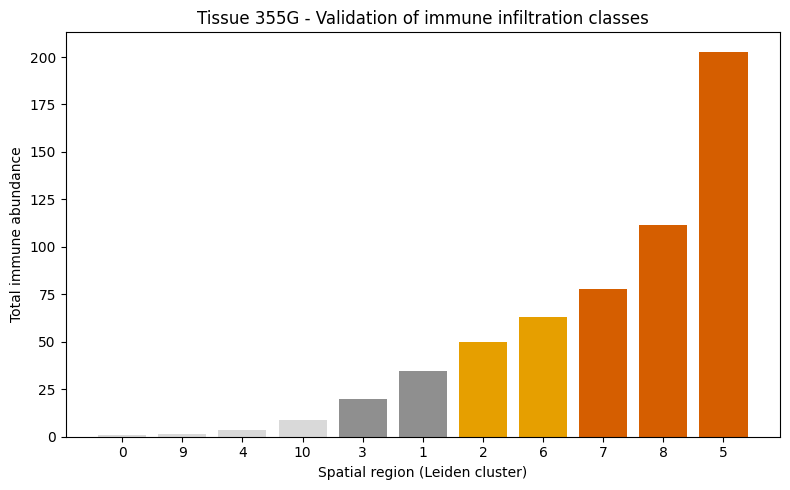

In [ ]:
#==============================================================
# FIGURE 8_X: VALIDATING IMMUNE CLASSES
#==============================================================
region_class_355G = (
    adata_355G.obs
    .groupby("leiden_0.4")["tissue_level_immune_class"]
    .first()
)
region_means_355G["tissue_level_immune_class"] = region_class_355G


# Order regions by abundance
plot_df = region_means_355G.sort_values("total_immune").copy()

# Assign colors
colors = plot_df["tissue_level_immune_class"].map(immune_palette_map)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    plot_df.index.astype(str),
    plot_df["total_immune"],
    color=colors
)

plt.xlabel("Spatial region")
plt.ylabel("Total immune abundance")
plt.title("Tissue 355G - Validation of immune infiltration classes")

plt.tight_layout()
plt.show()

In [ ]:
# -- Apparently you need to do all of this to color code a spatial object....
adata_355G.obs["tissue_level_immune_class"] = (
    adata_355G.obs["tissue_level_immune_class"]
    .astype("category")
)

adata_355G.obs["tissue_level_immune_class"] = (
    adata_355G.obs["tissue_level_immune_class"]
    .cat.reorder_categories(
        ["Immune-poor", "Immune-low", "Immune-moderate", "Immune-high"],
        ordered=True
    )
)

adata_355G.uns["tissue_level_immune_class_colors"] = [
    immune_palette_map[c]
    for c in adata_355G.obs["tissue_level_immune_class"].cat.categories
]

Text(0.5, 1.0, 'Immune Regions - Tissue 355G')

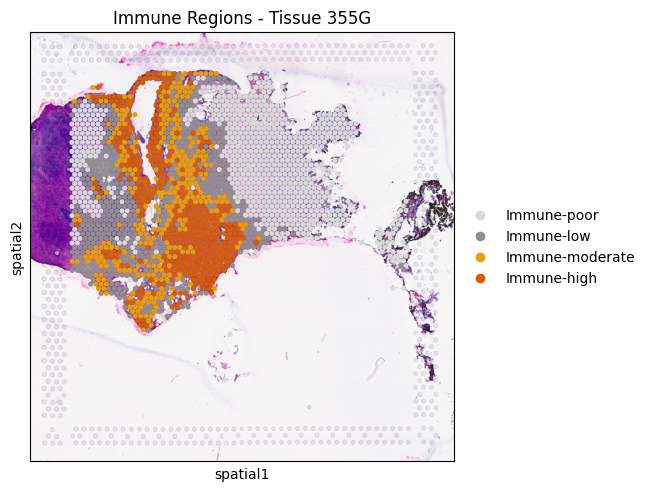

In [ ]:
#==============================================================
# FIGURE 8_12: IMMUNE REGION CLASSES TISSUE #2
#==============================================================
sq.pl.spatial_scatter(
    adata_355G,
    color="tissue_level_immune_class",
    size=1.5,
    img=False
)

plt.title("Immune Regions - Tissue 355G")
plt.savefig(
    os.path.join(output_path_figures, "08_355G_spatial_immune_region_class.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

LESION COMPARISONS

In [ ]:
#==============================================================
# LESION COMPARISONS
#==============================================================

df346 = adata_346.obs[
    ["total_immune_region_level","total_immune_spot_level","tissue_level_immune_class"]
].copy()

df346["tissue"] = "346"

df355G = adata_355G.obs[
    ["total_immune_region_level","total_immune_spot_level","tissue_level_immune_class"]
].copy()

df355G["tissue"] = "355G"


df346["tissue_level_immune_class"] = pd.Categorical(
    df346["tissue_level_immune_class"],
    categories=immune_class_order,
    ordered=True,
)

df355G["tissue_level_immune_class"] = pd.Categorical(
    df355G["tissue_level_immune_class"],
    categories=immune_class_order,
    ordered=True,
)


comparison_df = pd.concat([df346, df355G], ignore_index=True)

comparison_df["tissue_level_immune_class"] = pd.Categorical(
    comparison_df["tissue_level_immune_class"],
    categories=[
        "Immune-poor",
        "Immune-low",
        "Immune-moderate",
        "Immune-high"
    ],
    ordered=True
)

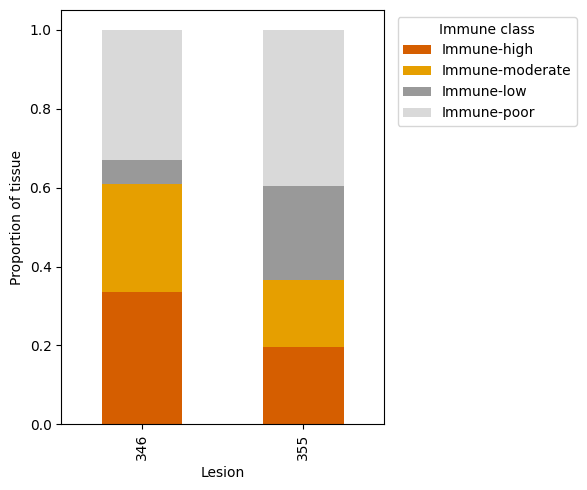

In [ ]:
#==============================================================
# FIGURE 8_X: IMMUNE CLASS PROPORTIONS BY TISSUE
#==============================================================

def immune_class_proportions(adata, class_col="tissue_level_immune_class"):
    return (
        adata.obs[class_col]
        .value_counts(normalize=True)
        .reindex(immune_class_order)
    )



def compare_immune_classes(adatas, labels, class_col="tissue_level_immune_class"):
  return pd.DataFrame({
        label: immune_class_proportions(adata, class_col)
        for adata, label in zip(adatas, labels)
    }).T

comparison = compare_immune_classes(
    [adata_346, adata_355G],
    ["346", "355"]
)


comparison.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5),
    color=[
        "#D55E00",
        "#E69F00",
        "#999999",
        "#D9D9D9"
    ]
)

plt.ylabel("Proportion of tissue")
plt.xlabel("Lesion")
plt.legend(title="Immune class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

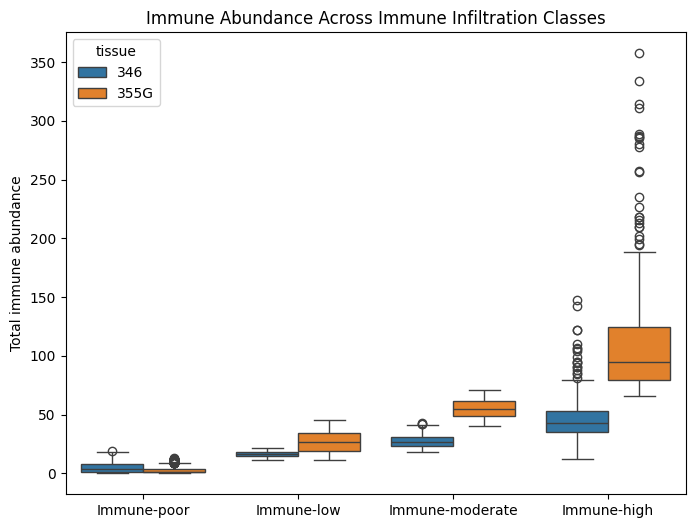

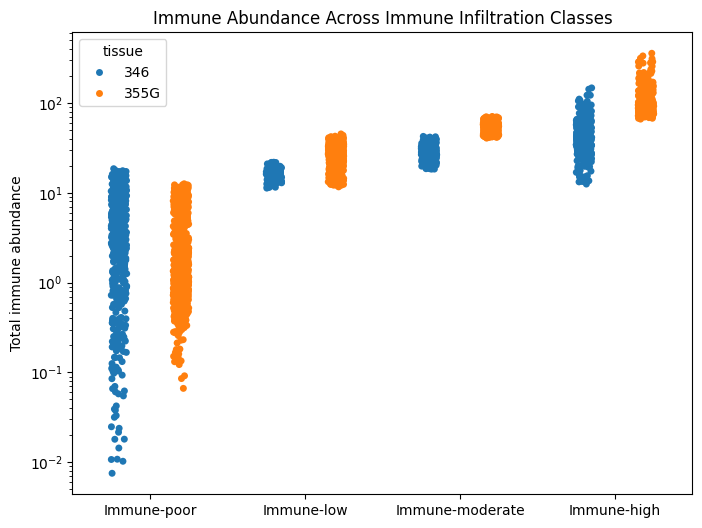

In [ ]:
#==============================================================
# FIGURE 8_X: IMMUNE ABUNDANCE BY IMMUNE CLASS PER TISSUE - BOX
#==============================================================
plt.figure(figsize=(8,6))

sns.boxplot(
    data=comparison_df,
    x="tissue_level_immune_class",
    y="total_immune_spot_level",
    hue="tissue"
)

plt.xlabel("")
plt.ylabel("Total immune abundance")
plt.title("Immune Abundance Across Immune Infiltration Classes")

plt.show()


plt.figure(figsize=(8,6))
sns.stripplot(
    data=comparison_df,
    x="tissue_level_immune_class",
    y="total_immune_spot_level",
    hue="tissue",
    dodge=True,
    size=5
)

plt.yscale("log")
plt.xlabel("")
plt.ylabel("Total immune abundance")
plt.title("Immune Abundance Across Immune Infiltration Classes")

plt.show()


/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/tmp/ipykernel_21433/130408245.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


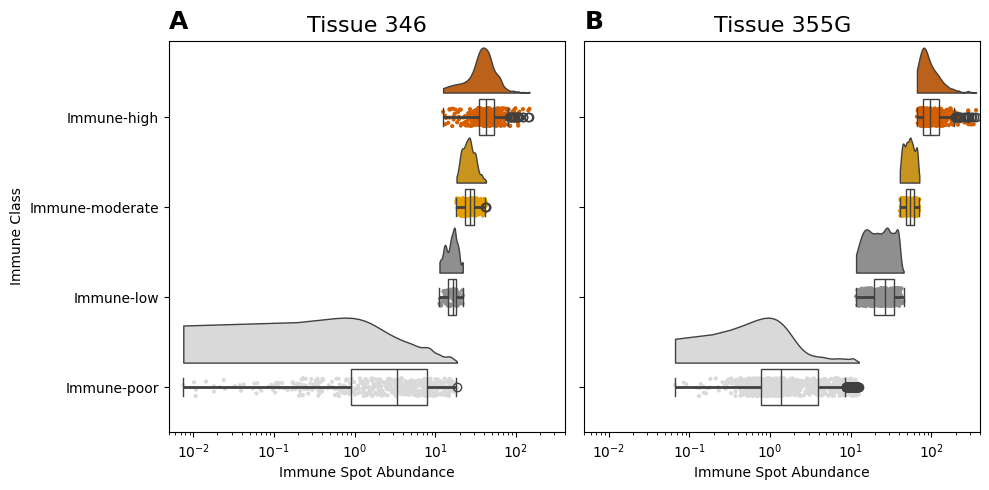

In [ ]:
# -- Going to attempt making a raincloud plot
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, constrained_layout=True)

pt.RainCloud(
    data=df346,
    x="tissue_level_immune_class",
    y="total_immune_spot_level",
    width_viol= 1,
    width_box=0.4,
    hue="tissue_level_immune_class",
    palette=immune_palette,
    orient="h",
    ax=ax[0]
)

pt.RainCloud(
    data=df355G,
    x="tissue_level_immune_class",
    y="total_immune_spot_level",
    width_viol= 1,
    width_box=0.4,
    hue="tissue_level_immune_class",
    palette=immune_palette,
    orient="h",
    ax=ax[1]
)


ax[0].text(
    0, 1.03, "A",
    transform=ax[0].transAxes,
    fontsize=18,
    fontweight="bold"
)

ax[1].text(
    0, 1.03, "B",
    transform=ax[1].transAxes,
    fontsize=18,
    fontweight="bold"
)

ax[0].set_title("BEME346", fontsize=15)
ax[1].set_title("BEME355G", fontsize=15)
ax[0].set_xlabel("Immune Spot Abundance")
ax[0].set_ylabel("Immune Class")
ax[0].set_title("Tissue 346", fontsize=16)


ax[1].set_xlabel("Immune Spot Abundance")
ax[1].set_ylabel("")
for a in ax:
    a.set_xscale("log")
    a.set_xlim(0.005, 400)
ax[1].set_title("Tissue 355G", fontsize=16)

plt.tight_layout()

In [ ]:
#==============================================================
# 346 - TISSUE LEVEL ABUNDANCE WITH DOMINANT CELL TYPES
#==============================================================
summary_346 = (
    region_means_346[
        ["tissue_level_immune_class", "total_immune"]
    ]
    .sort_values("total_immune", ascending=False)
)

summary_346.index.name = "Region"

summary_346["Dominant cell type"] = (
    region_means_346[cell_columns]
    .idxmax(axis=1)
)

summary_346

,tissue_level_immune_class,total_immune,Dominant cell type
Region,,,
0,Immune-high,63.734684,Tissue Resident Macrophages
4,Immune-high,39.791420,Tissue Resident Macrophages
1,Immune-high,33.922020,Classical Monocytes
6,Immune-moderate,28.656706,Tissue Resident Macrophages
7,Immune-moderate,26.048080,γδ T cells
8,Immune-low,16.442678,γδ T cells
2,Immune-poor,9.150543,Tissue Resident Macrophages
3,Immune-poor,3.031461,Dendritic cells
5,Immune-poor,0.316276,Dendritic cells


In [ ]:
#==============================================================
# 355G - TISSUE LEVEL ABUNDANCE WITH DOMINANT CELL TYPES
#==============================================================
summary_355G = (
    region_means_355G[
        ["tissue_level_immune_class", "total_immune"]
    ]
    .sort_values("total_immune", ascending=False)
)

summary_355G.index.name = "Region"

summary_355G["Dominant cell type"] = (
    region_means_355G[cell_columns]
    .idxmax(axis=1)
)

summary_355G

,tissue_level_immune_class,total_immune,Dominant cell type
Region,,,
5,Immune-high,202.857101,Tissue Resident Macrophages
8,Immune-high,111.395790,Tissue Resident Macrophages
7,Immune-high,77.912941,Tissue Resident Macrophages
6,Immune-moderate,63.222656,Tissue Resident Macrophages
2,Immune-moderate,49.634388,Tissue Resident Macrophages
1,Immune-low,34.485027,Tissue Resident Macrophages
3,Immune-low,19.735086,Tissue Resident Macrophages
10,Immune-poor,8.723889,Tissue Resident Macrophages
4,Immune-poor,3.803365,Tissue Resident Macrophages


In [ ]:
summary_355G = (
    region_means_355G[
        ["tissue_level_immune_class", "total_immune"]
    ]
    .sort_values("total_immune", ascending=False)
)


In [ ]:
#==============================================================
# SUMMARY TABLE
#==============================================================
region_summary_346 = (
    adata_346.obs
    .groupby("leiden_0.4")["tissue_level_immune_class"]
    .first()
    .value_counts()
    .reindex(immune_class_order)
)

region_summary_355G = (
    adata_355G.obs
    .groupby("leiden_0.4")["tissue_level_immune_class"]
    .first()
    .value_counts()
    .reindex(immune_class_order)
)

region_summary = pd.DataFrame({
    "BEME346": region_summary_346,
    "BEME355G": region_summary_355G
}).T

region_summary["Spatial regions"] = [
    adata_346.obs["leiden_0.4"].nunique(),
    adata_355G.obs["leiden_0.4"].nunique()
]

region_summary = region_summary[
    ["Spatial regions"] + immune_class_order
]

region_summary

/tmp/ipykernel_21433/2580242052.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")["tissue_level_immune_class"]
/tmp/ipykernel_21433/2580242052.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_0.4")["tissue_level_immune_class"]


tissue_level_immune_class,Spatial regions,Immune-high,Immune-moderate,Immune-low,Immune-poor
BEME346,9,3,2,1,3
BEME355G,11,3,2,2,4


In [ ]:
# -- SAVE DATA
adata_346.write_h5ad(
    os.path.join(output_path_data, "BEME346_spatial_immune_architecture.h5ad")
)

adata_355G.write_h5ad(
    os.path.join(output_path_data, "BEME355G_spatial_immune_architecture.h5ad")
)